In [1]:
# 1. Imports
import sys
import os
import pandas as pd
from IPython.display import display

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, econometrics, config

target_volatility = 'Sq_Log_Return'

# macro_shocks = ['CPI_Surprise', 'PPI_Surprise', 'FedFunds_Diff'] # The Inflation & Policy Block
# macro_shocks = ['Unemployment_Surprise', 'Housing_Starts_Surprise'] # The Real Economy Block
macro_shocks = ['Trade_Balance_Surprise', 'M1_Money_Surprise'] # The Global & Liquidity Block

raw_data_dict = data_loader.fetch_raw_data()

# Dictionaries to store our multi-sector results
sector_models = {}
sector_stats = {}
sector_var_data = {}

2026-06-16 22:05:00 - src.data_loader - INFO - Configuration matches cache. Loading data from disk...


In [2]:
# 2. Multi-Sector Processing Loop
for etf in config.TARGET_ETFS:
    print(f"\n" + "="*50)
    print(f"PROCESSING SECTOR: {etf}")
    print("="*50)
    
    # Engineer Features
    raw_df = raw_data_dict[etf]
    stat_df = features.engineer_stationary_features(raw_df, etf_name=etf)
    
    # Prepare VAR Data
    var_data = econometrics.prepare_var_data(stat_df, target_vol_col=target_volatility, macro_cols=macro_shocks)
    sector_var_data[etf] = var_data
    
    # Granger Causality
    econometrics.test_granger_causality(var_data, sector_name=etf, max_lag=5)
    
    # Fit VAR Model (Only printing AIC table for the first ETF to save space)
    print(f"\nFitting VAR Model for {etf}...")
    is_first = (etf == config.TARGET_ETFS[0])
    results, optimal_lag = econometrics.fit_var_model(var_data, max_lags=9, verbose=is_first)
    
    sector_models[etf] = results
    
    # Extract Equation Stats
    stats_df = econometrics.get_equation_stats(results, target_vol_col=target_volatility)
    sector_stats[etf] = stats_df


2026-06-16 22:05:00 - src.features - INFO - Engineering features and macro surprises for XLK...
2026-06-16 22:05:00 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLK

--- Granger Causality: Macro -> XLK ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0556 *
  Lag 2: p-value = 0.3292 
  Lag 3: p-value = 0.6210 
  Lag 4: p-value = 0.7146 
  Lag 5: p-value = 0.8590 
[M1_Money_Surprise]
  Lag 1: p-value = 0.5513 
  Lag 2: p-value = 0.8849 
  Lag 3: p-value = 0.9532 
  Lag 4: p-value = 0.9868 
  Lag 5: p-value = 0.9962 

Fitting VAR Model for XLK...


2026-06-16 22:05:03 - src.features - INFO - Engineering features and macro surprises for XLE...
2026-06-16 22:05:03 - src.features - INFO - Calculating Autoregressive Macro Surprises...



LAG SELECTION CRITERIA
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       17.25       17.26   3.115e+07       17.26
1       12.24       12.25   2.059e+05       12.24
2       12.19       12.21   1.961e+05       12.19
3       12.18       12.21   1.949e+05       12.19
4       12.16       12.21   1.919e+05       12.18
5       12.15       12.20   1.897e+05       12.17
6       12.13      12.19*   1.861e+05       12.15
7       12.13       12.20   1.862e+05       12.16
8       12.12       12.20   1.840e+05      12.15*
9      12.12*       12.21  1.837e+05*       12.15
-------------------------------------------------

PROCESSING SECTOR: XLE

--- Granger Causality: Macro -> XLE ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0096 ***
  Lag 2: p-value = 0.1331 
  Lag 3: p-value = 0.3804 
  Lag 4: p-value = 0.7195 
  Lag 5: p-value = 0.8843 
[M1_Money_Surprise]
  Lag 1: p-value = 0.2019 
 

2026-06-16 22:05:05 - src.features - INFO - Engineering features and macro surprises for XLF...
2026-06-16 22:05:05 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLF

--- Granger Causality: Macro -> XLF ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0000 ***
  Lag 2: p-value = 0.0000 ***
  Lag 3: p-value = 0.0000 ***
  Lag 4: p-value = 0.0008 ***
  Lag 5: p-value = 0.0057 ***
[M1_Money_Surprise]
  Lag 1: p-value = 0.0941 *
  Lag 2: p-value = 0.3651 
  Lag 3: p-value = 0.6331 
  Lag 4: p-value = 0.8289 
  Lag 5: p-value = 0.9322 

Fitting VAR Model for XLF...


2026-06-16 22:05:08 - src.features - INFO - Engineering features and macro surprises for XLV...
2026-06-16 22:05:08 - src.features - INFO - Calculating Autoregressive Macro Surprises...



PROCESSING SECTOR: XLV

--- Granger Causality: Macro -> XLV ---
[Trade_Balance_Surprise]
  Lag 1: p-value = 0.0039 ***
  Lag 2: p-value = 0.1726 
  Lag 3: p-value = 0.3727 
  Lag 4: p-value = 0.2119 
  Lag 5: p-value = 0.3661 
[M1_Money_Surprise]
  Lag 1: p-value = 0.1926 
  Lag 2: p-value = 0.5331 
  Lag 3: p-value = 0.7737 
  Lag 4: p-value = 0.8878 
  Lag 5: p-value = 0.9511 

Fitting VAR Model for XLV...


In [3]:
# 3. SIDE-BY-SIDE EQUATION COMPARISON
print("\n" + "="*80)
print("MULTI-SECTOR VAR EQUATION COMPARISON")
print("="*80)
# This magical pandas function stitches all the sector tables together side-by-side
combined_stats = pd.concat(sector_stats.values(), axis=1, keys=sector_stats.keys())
display(combined_stats.fillna('-'))


MULTI-SECTOR VAR EQUATION COMPARISON


XLK                  XLE                  XLF  \
                             Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                      0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L1.Trade_Balance_Surprise  0.0000  0.7066      -0.0000  0.8484       0.0000   
L1.M1_Money_Surprise       0.0000  0.9611       0.0000  0.7019       0.0000   
L1.Sq_Log_Return           0.1395  0.0000  *** -0.0060  0.6316       0.1372   
L2.Trade_Balance_Surprise  0.0000  0.9616      -0.0000  0.9461       0.0000   
L2.M1_Money_Surprise       0.0000  0.8049      -0.0000  0.9264       0.0000   
L2.Sq_Log_Return           0.1412  0.0000  ***  0.1489  0.0000  ***  0.0931   
L3.Trade_Balance_Surprise  0.0000  0.5584       0.0000  0.3744       0.0000   
L3.M1_Money_Surprise      -0.0000  0.7612       0.0000  0.9961       0.0000   
L3.Sq_Log_Return           0.0213  0.0922    *  0.0956  0.0000  ***  0.0462   
L4.Trade_Balance_Surprise -0.0000  0.2721      -0.0000  0.3268      -0.0000   
L4.M1_Money_Surprise      -0.0000  0.9850       0.0000  0.1926       0.0000   
L4.Sq_Log_Return           0.0723  0.0000  ***  0.1705  0.0000  ***  0.0992   
L5.Trade_Balance_Surprise -0.0000  0.9543       0.0000  0.8723       0.0000   
L5.M1_Money_Surprise       0.0000  0.9285      -0.0000  0.1080      -0.0000   
L5.Sq_Log_Return           0.0815  0.0000  ***  0.1665  0.0000  ***  0.0573   
L6.Trade_Balance_Surprise  0.0000  0.8633      -0.0000  0.9818      -0.0000   
L6.M1_Money_Surprise      -0.0000  0.8831       0.0000  0.7420       0.0000   
L6.Sq_Log_Return           0.0984  0.0000  ***  0.0366  0.0033  ***  0.2031   
L7.Trade_Balance_Surprise  0.0000  0.8499      -0.0000  0.4445      -0.0000   
L7.M1_Money_Surprise       0.0000  0.8485      -0.0000  0.3666      -0.0000   
L7.Sq_Log_Return           0.0054  0.6687       0.1664  0.0000  ***  0.0626   
L8.Trade_Balance_Surprise -0.0000  0.9611       0.0000  0.1967       0.0000   
L8.M1_Money_Surprise       0.0000  0.2094       0.0000  0.0374   **  0.0000   
L8.Sq_Log_Return           0.1046  0.0000  ***  0.0107  0.3901      -0.0003   
L9.Trade_Balance_Surprise  0.0000  0.9349      -0.0000  0.7377      -0.0000   
L9.M1_Money_Surprise      -0.0000  0.0558    * -0.0000  0.0643    * -0.0000   
L9.Sq_Log_Return           0.0424  0.0007  *** -0.0439  0.0004  ***  0.0790   

                                           XLV               
                            P-Val  Sig    Coef   P-Val  Sig  
const                      0.0000  ***  0.0000  0.0000  ***  
L1.Trade_Balance_Surprise  0.8546       0.0000  0.9433       
L1.M1_Money_Surprise       0.9082      -0.0000  0.5533       
L1.Sq_Log_Return           0.0000  ***  0.1343  0.0000  ***  
L2.Trade_Balance_Surprise  0.8873      -0.0000  0.8247       
L2.M1_Money_Surprise       0.8649       0.0000  0.5812       
L2.Sq_Log_Return           0.0000  ***  0.3587  0.0000  ***  
L3.Trade_Balance_Surprise  0.4828       0.0000  0.0868    *  
L3.M1_Money_Surprise       0.9919       0.0000  0.9469       
L3.Sq_Log_Return           0.0002  ***  0.0615  0.0000  ***  
L4.Trade_Balance_Surprise  0.1945      -0.0000  0.1954       
L4.M1_Money_Surprise       0.9656      -0.0000  0.9392       
L4.Sq_Log_Return           0.0000  *** -0.0432  0.0011  ***  
L5.Trade_Balance_Surprise  0.3909      -0.0000  0.3893       
L5.M1_Money_Surprise       0.8009      -0.0000  0.9441       
L5.Sq_Log_Return           0.0000  ***  0.0483  0.0003  ***  
L6.Trade_Balance_Surprise  0.8853       0.0000  0.7669       
L6.M1_Money_Surprise       0.8235       0.0000  0.9412       
L6.Sq_Log_Return           0.0000  ***  0.0189  0.1545       
L7.Trade_Balance_Surprise  0.8225       0.0000  0.5543       
L7.M1_Money_Surprise       0.9116      -0.0000  0.8568       
L7.Sq_Log_Return           0.0000  ***  0.0276  0.0374   **  
L8.Trade_Balance_Surprise  0.0141   **  0.0000  0.9325       
L8.M1_Money_Surprise       0.3526       0.0000  0.0129   **  
L8.Sq_Log_Return           0.9803       0.1057 

In [4]:
to_show = combined_stats[combined_stats.xs("Sig", axis=1, level=1).isin(["*","**","***"]).any(axis=1)]
display(to_show[~to_show.index.astype(str).str.contains("Return")])

XLK                  XLE                  XLF  \
                             Coef   P-Val  Sig    Coef   P-Val  Sig    Coef   
const                      0.0001  0.0000  ***  0.0001  0.0000  ***  0.0001   
L3.Trade_Balance_Surprise  0.0000  0.5584       0.0000  0.3744       0.0000   
L8.Trade_Balance_Surprise -0.0000  0.9611       0.0000  0.1967       0.0000   
L8.M1_Money_Surprise       0.0000  0.2094       0.0000  0.0374   **  0.0000   
L9.Trade_Balance_Surprise  0.0000  0.9349      -0.0000  0.7377      -0.0000   
L9.M1_Money_Surprise      -0.0000  0.0558    * -0.0000  0.0643    * -0.0000   

                                        XLV               
                            P-Val  Sig Coef   P-Val  Sig  
const                      0.0000  ***  0.0  0.0000  ***  
L3.Trade_Balance_Surprise  0.4828       0.0  0.0868    *  
L8.Trade_Balance_Surprise  0.0141   **  0.0  0.9325       
L8.M1_Money_Surprise       0.3526       0.0  0.0129   **  
L9.Trade_Balance_Surprise  0.0018  *** -0.0  0.8324       
L9.M1_Money_Surprise       0.1919      -0.0  0.0009  ***


VISUAL DIAGNOSTICS: XLK


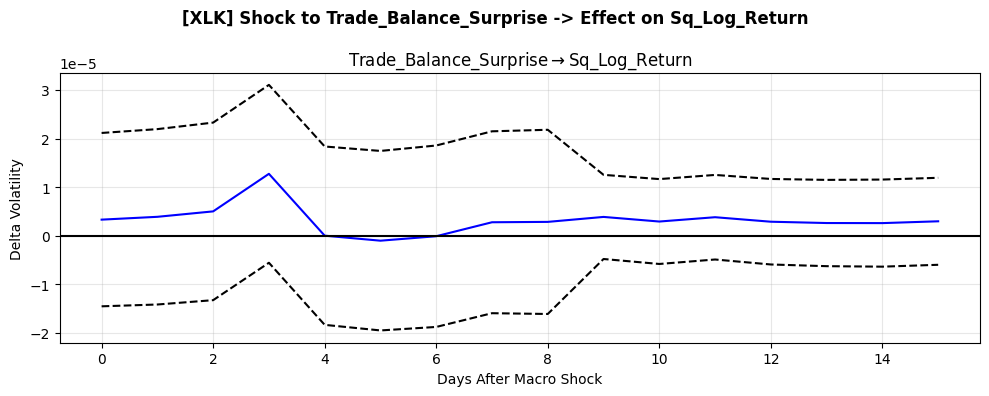

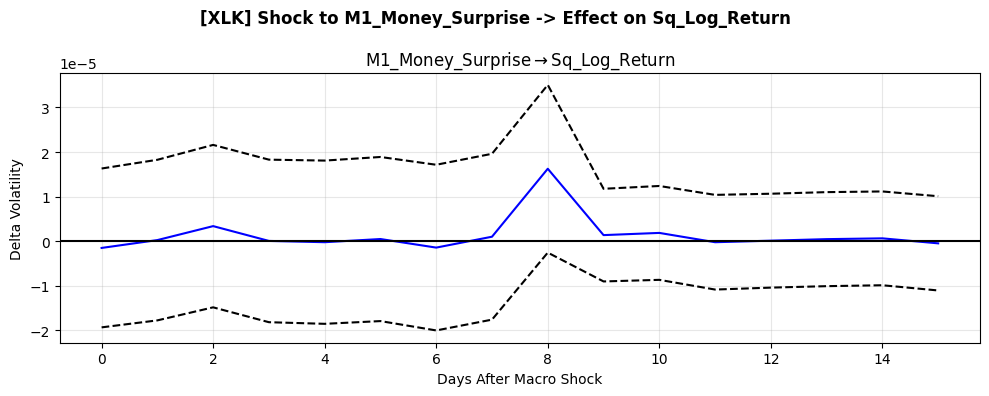

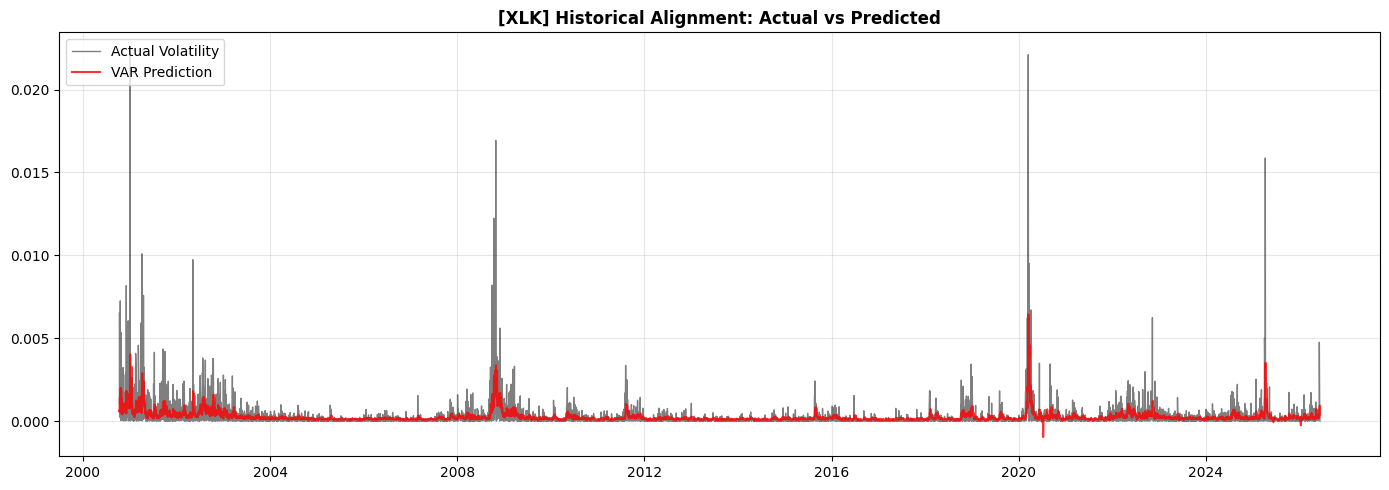


VISUAL DIAGNOSTICS: XLE


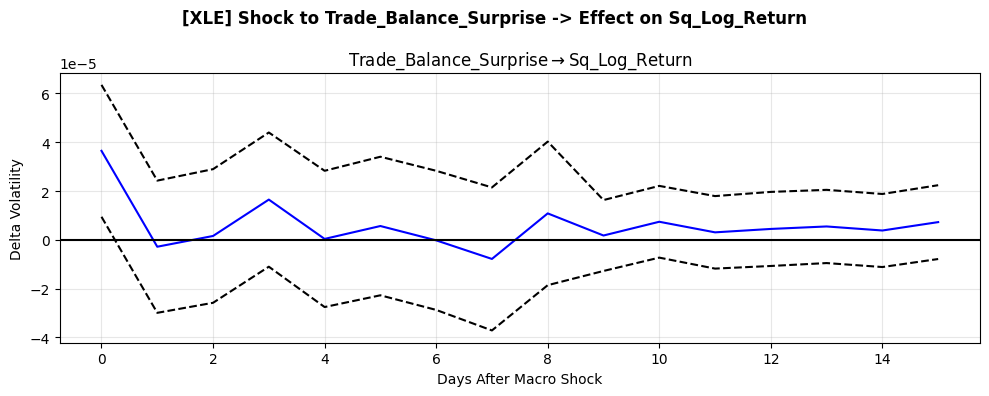

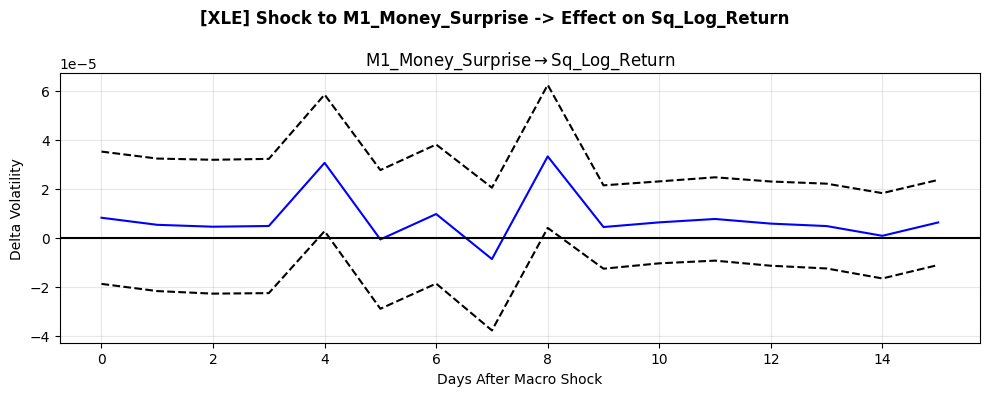

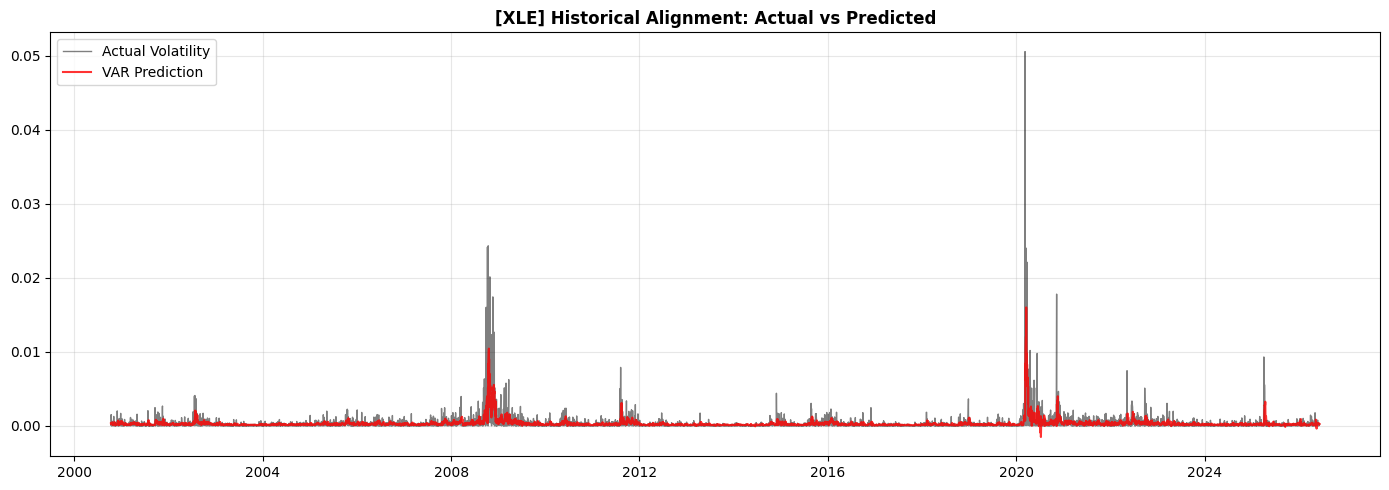


VISUAL DIAGNOSTICS: XLF


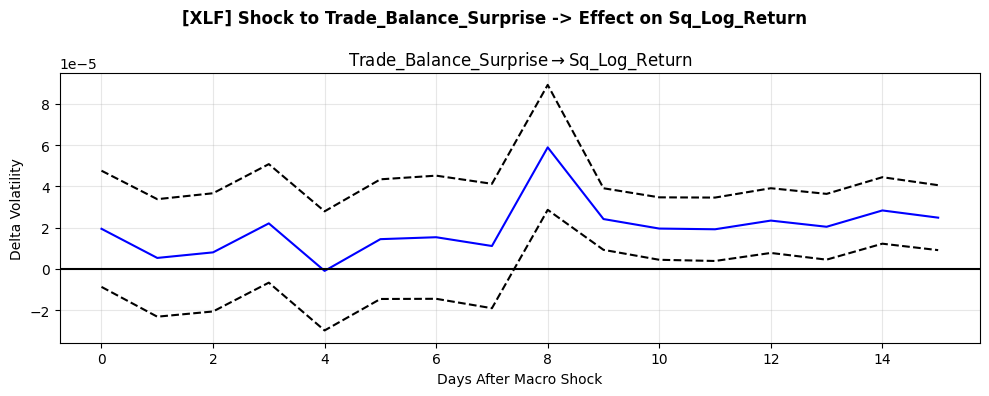

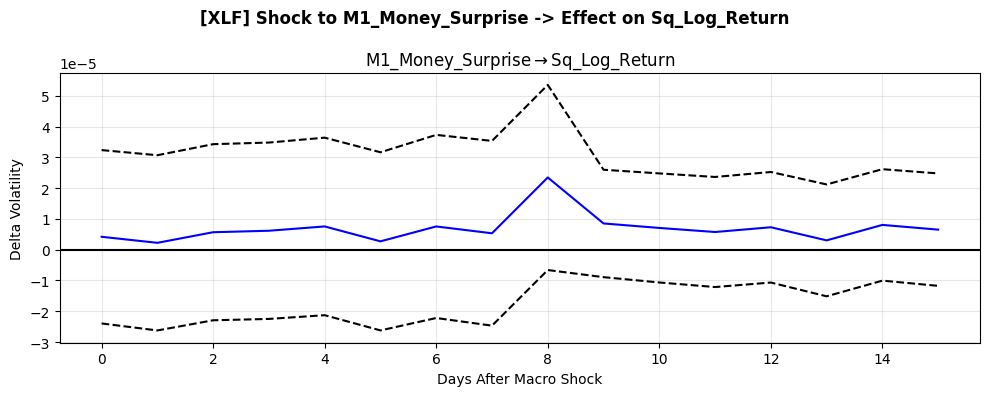

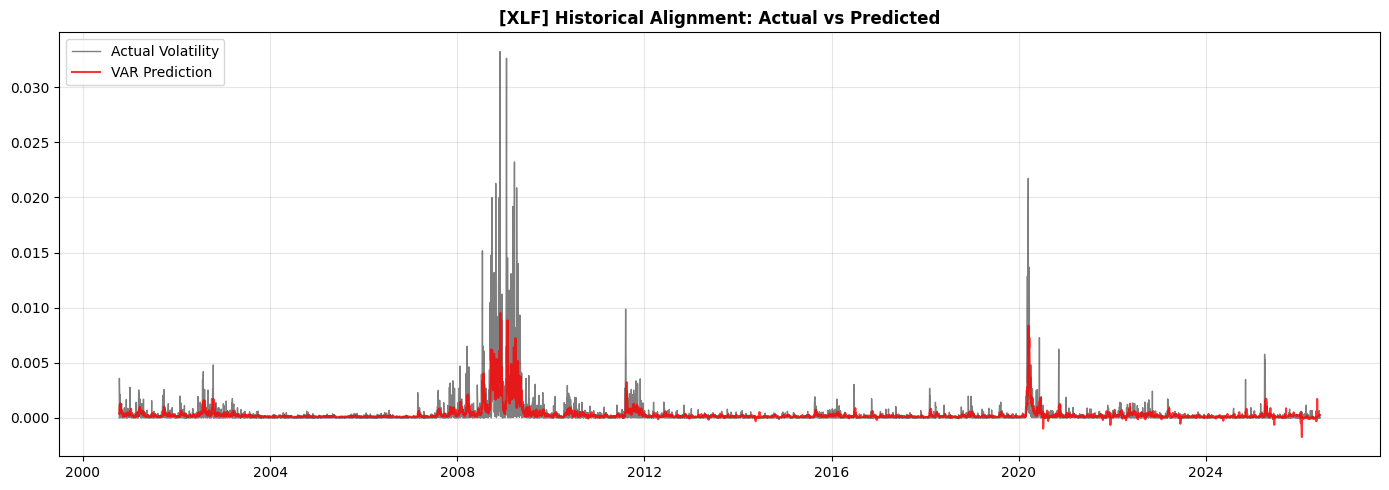


VISUAL DIAGNOSTICS: XLV


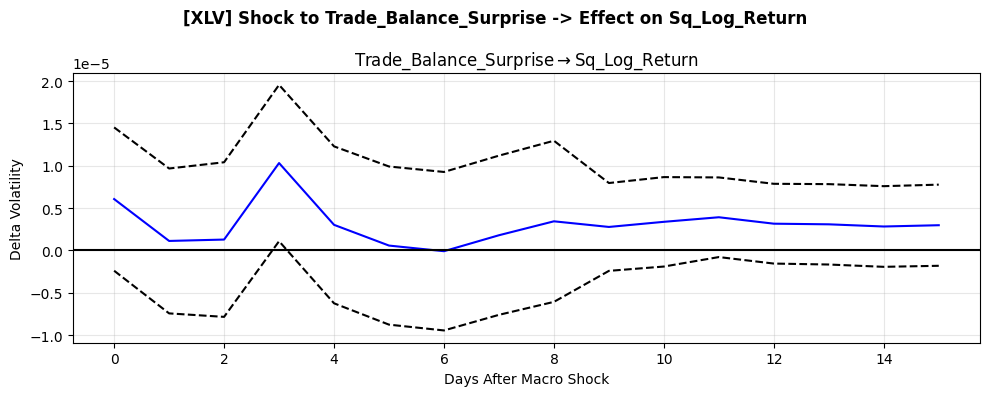

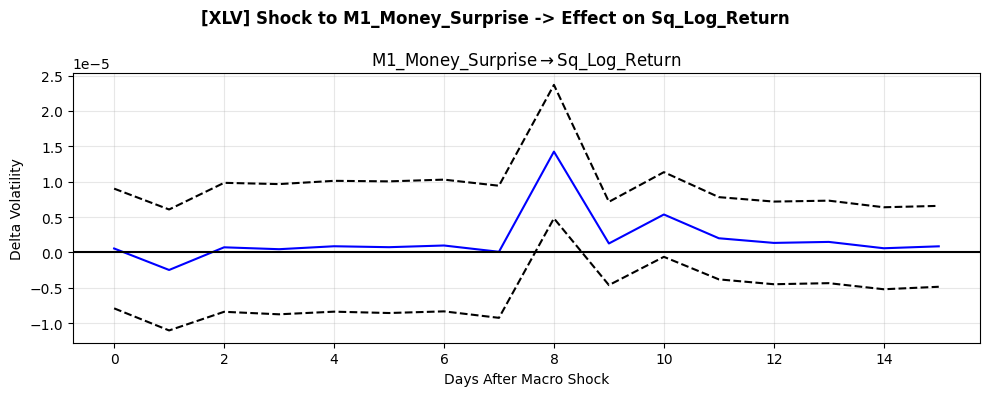

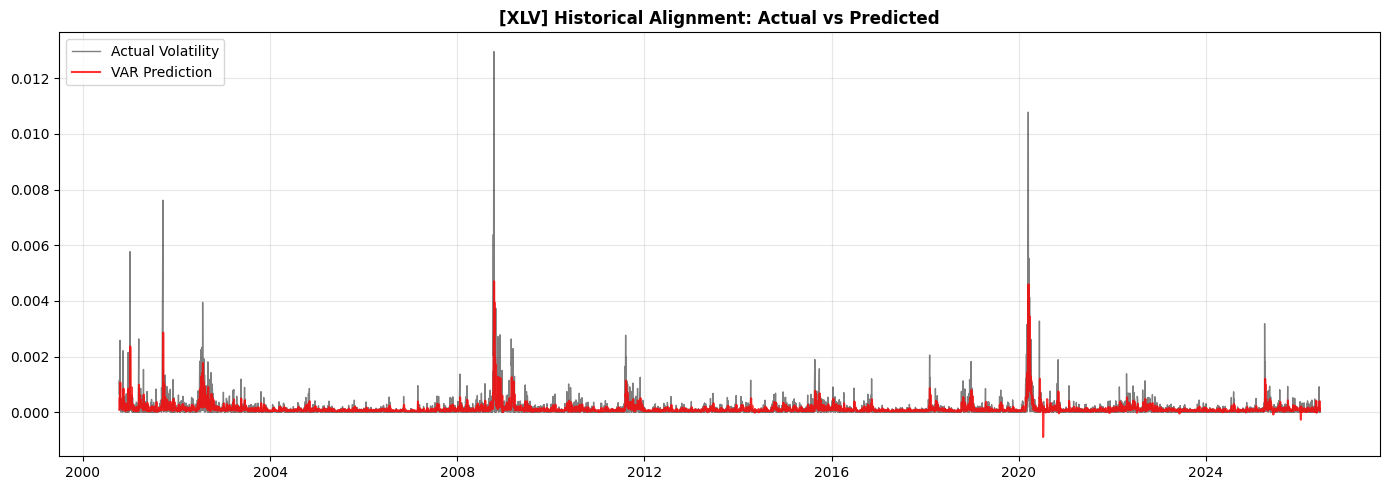

In [5]:
# 4. VISUALIZATIONS
for etf in config.TARGET_ETFS:
    print("\n" + "="*80)
    print(f"VISUAL DIAGNOSTICS: {etf}")
    print("="*80)
    
    results = sector_models[etf]
    var_data = sector_var_data[etf]
    
    econometrics.plot_irfs(results, var_data, sector_name=etf, irf_periods=15)
    econometrics.plot_historical_fit(results, var_data, sector_name=etf)
